In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

engine = create_engine("postgresql://karnisinghrathore@localhost:5432/freight_analytics")
df = pd.read_sql("SELECT * FROM fact_freight_analysis ORDER BY quarter_date", engine)
df["quarter_date"] = pd.to_datetime(df["quarter_date"])

print(f"Loaded {len(df)} rows")
df.head()

Loaded 115 rows


,quarter_date,freight_cost,fuel_index,wage_index,cpi_index
0,1997-09-01,64.3,37.69,66.6,46.28
1,1997-12-01,65.0,38.13,67.2,46.39
2,1998-03-01,64.7,36.47,67.8,46.51
3,1998-06-01,65.2,36.79,68.3,46.78
4,1998-09-01,65.2,35.99,68.8,46.91


Correlation with freight_cost:
freight_cost    1.000000
cpi_index       0.992288
wage_index      0.992286
fuel_index      0.935418
Name: freight_cost, dtype: float64


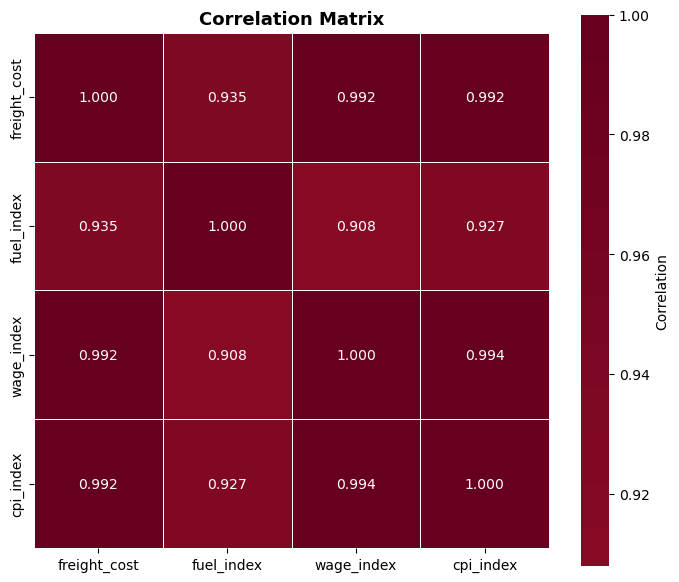

In [ ]:
# Correlation of every variable with every other (Pearson by default)
corr = df[["freight_cost", "fuel_index", "wage_index", "cpi_index"]].corr()

print("Correlation with freight_cost:")
print(corr["freight_cost"].sort_values(ascending=False))

# Heatmap of the full correlation matrix
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={"label": "Correlation"})
ax.set_title("Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

#too much co relation because they all rose from their base values in 1997.
#therefore lets just focus on the difference quater wise to see if they change in the same way.

Correlation of QUARTERLY CHANGES with freight change:
freight_cost    1.000000
cpi_index       0.328771
wage_index      0.282120
fuel_index      0.143281
Name: freight_cost, dtype: float64


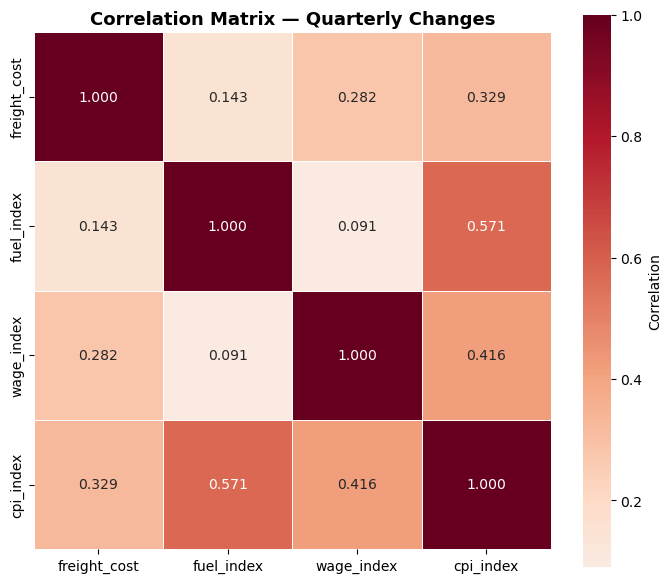

In [4]:
# Quarter-on-quarter CHANGE (first difference) removes the shared upward trend
changes = df[["freight_cost", "fuel_index", "wage_index", "cpi_index"]].diff().dropna()

corr_changes = changes.corr()

print("Correlation of QUARTERLY CHANGES with freight change:")
print(corr_changes["freight_cost"].sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_changes, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={"label": "Correlation"})
ax.set_title("Correlation Matrix — Quarterly Changes", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Correlation of freight change vs fuel change at various lags:
(lag = how many quarters fuel is shifted EARLIER than freight)

  fuel lagged 0 quarter(s): 0.143
  fuel lagged 1 quarter(s): 0.503
  fuel lagged 2 quarter(s): 0.264
  fuel lagged 3 quarter(s): 0.118
  fuel lagged 4 quarter(s): 0.090


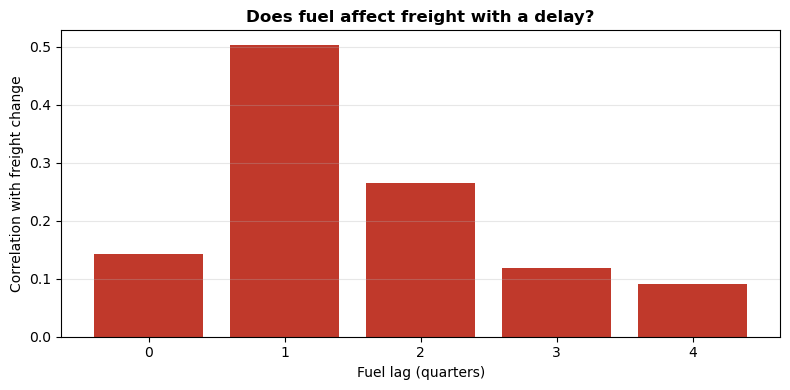

In [5]:
# Does fuel affect freight with a DELAY? Test fuel changes lagged 0-4 quarters.
freight_chg = df["freight_cost"].diff()
fuel_chg = df["fuel_index"].diff()

print("Correlation of freight change vs fuel change at various lags:")
print("(lag = how many quarters fuel is shifted EARLIER than freight)\n")

results = []
for lag in range(0, 5):
    # shift fuel's change forward so past fuel lines up with current freight
    corr = freight_chg.corr(fuel_chg.shift(lag))
    results.append((lag, corr))
    print(f"  fuel lagged {lag} quarter(s): {corr:.3f}")

# Quick bar chart of the lag profile
lags, corrs = zip(*results)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(lags, corrs, color="#c0392b")
ax.set_xlabel("Fuel lag (quarters)")
ax.set_ylabel("Correlation with freight change")
ax.set_title("Does fuel affect freight with a delay?", fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

Correlation of freight change vs each driver's change, by lag:

 lag |    fuel |    wage |     cpi
----------------------------------
   0 |   0.143 |   0.282 |   0.329
   1 |   0.503 |   0.311 |   0.443
   2 |   0.264 |   0.078 |   0.116
   3 |   0.118 |   0.044 |   0.050
   4 |   0.090 |  -0.057 |   0.005


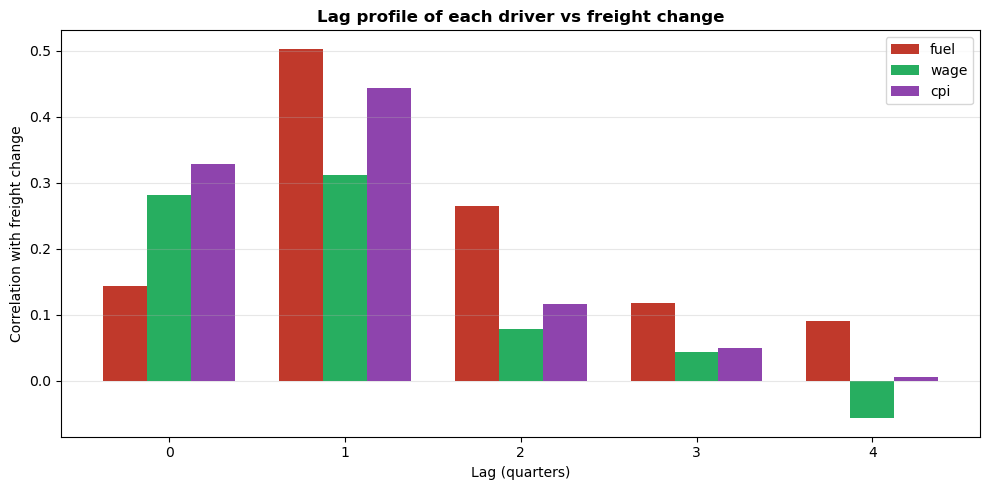

In [6]:
# Lag-test ALL three drivers: which lag gives the strongest link to freight change?
freight_chg = df["freight_cost"].diff()
driver_cols = {"fuel_index": "#c0392b", "wage_index": "#27ae60", "cpi_index": "#8e44ad"}

fig, ax = plt.subplots(figsize=(10, 5))
width = 0.25

print("Correlation of freight change vs each driver's change, by lag:\n")
print(f"{'lag':>4} | {'fuel':>7} | {'wage':>7} | {'cpi':>7}")
print("-" * 34)

# collect correlations: {driver: [corr at lag0, lag1, ...]}
lag_range = range(0, 5)
profiles = {}
for col in driver_cols:
    chg = df[col].diff()
    profiles[col] = [freight_chg.corr(chg.shift(lag)) for lag in lag_range]

for lag in lag_range:
    print(f"{lag:>4} | {profiles['fuel_index'][lag]:>7.3f} | "
          f"{profiles['wage_index'][lag]:>7.3f} | {profiles['cpi_index'][lag]:>7.3f}")

# grouped bar chart
for i, (col, colour) in enumerate(driver_cols.items()):
    offsets = [l + (i - 1) * width for l in lag_range]
    ax.bar(offsets, profiles[col], width, label=col.replace("_index", ""), color=colour)

ax.set_xlabel("Lag (quarters)")
ax.set_ylabel("Correlation with freight change")
ax.set_title("Lag profile of each driver vs freight change", fontweight="bold")
ax.set_xticks(list(lag_range))
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

In [7]:
import statsmodels.api as sm

# Build a modelling table: freight change vs each driver's change LAGGED 1 quarter
model_df = pd.DataFrame({
    "freight_chg": df["freight_cost"].diff(),
    "fuel_chg_lag1": df["fuel_index"].diff().shift(1),
    "wage_chg_lag1": df["wage_index"].diff().shift(1),
    "cpi_chg_lag1":  df["cpi_index"].diff().shift(1),
}).dropna()   # drop rows with NaN from diff + shift

print(f"Modelling on {len(model_df)} quarters\n")

# X = predictors, y = target
X = model_df[["fuel_chg_lag1", "wage_chg_lag1", "cpi_chg_lag1"]]
y = model_df["freight_chg"]

# Add an intercept term (statsmodels needs this explicitly)
X = sm.add_constant(X)

# Fit Ordinary Least Squares regression
model = sm.OLS(y, X).fit()
print(model.summary())

Modelling on 113 quarters

                            OLS Regression Results                            
Dep. Variable:            freight_chg   R-squared:                       0.334
Model:                            OLS   Adj. R-squared:                  0.316
Method:                 Least Squares   F-statistic:                     18.22
Date:                Mon, 15 Jun 2026   Prob (F-statistic):           1.18e-09
Time:                        09:14:58   Log-Likelihood:                -172.51
No. Observations:                 113   AIC:                             353.0
Df Residuals:                     109   BIC:                             363.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0

In [8]:
# Refit WITHOUT cpi (it was redundant with fuel due to multicollinearity)
X2 = model_df[["fuel_chg_lag1", "wage_chg_lag1"]]
y2 = model_df["freight_chg"]
X2 = sm.add_constant(X2)

model2 = sm.OLS(y2, X2).fit()
print(model2.summary())

# Quick side-by-side of the two models
print("\n--- Model comparison ---")
print(f"{'':20} {'3-driver':>12} {'2-driver':>12}")
print(f"{'R-squared':20} {model.rsquared:>12.3f} {model2.rsquared:>12.3f}")
print(f"{'Adj. R-squared':20} {model.rsquared_adj:>12.3f} {model2.rsquared_adj:>12.3f}")
print(f"{'AIC':20} {model.aic:>12.1f} {model2.aic:>12.1f}")

                            OLS Regression Results                            
Dep. Variable:            freight_chg   R-squared:                       0.327
Model:                            OLS   Adj. R-squared:                  0.315
Method:                 Least Squares   F-statistic:                     26.74
Date:                Mon, 15 Jun 2026   Prob (F-statistic):           3.44e-10
Time:                        09:27:48   Log-Likelihood:                -173.10
No. Observations:                 113   AIC:                             352.2
Df Residuals:                     110   BIC:                             360.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.5599      0.336     -1.665

In [ ]:
# Freight cost movements are driven by fuel and wage costs, both with a one-quarter lag. Fuel is the most statistically robust driver (p < 0.001); wages contribute significantly (p = 0.001). General inflation (CPI) was tested but excluded — it had no independent effect once fuel was controlled for (multicollinearity, fuel–CPI r = 0.57), and removing it produced a simpler model with equal explanatory power and lower AIC. The model explains ~33% of quarter-to-quarter freight variation, with crisis-period shocks (GFC, COVID) as unexplained outliers.